<a href="https://colab.research.google.com/github/sergiomorapardo/StochasticAITechniquesClass/blob/main/Notebooks/L13_iforest_heristics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Detección de Fraude por Incentivos (Altas Fantasma)

En el ámbito comercial moderno, el diseño de esquemas de comisiones y bonos tiene como objetivo alinear los incentivos de la fuerza de ventas con los objetivos de crecimiento de la compañía. Sin embargo, cuando estos incentivos no se blindan analíticamente, pueden desencadenar comportamientos oportunistas.

En nuestro caso de estudio en Telecomunicaciones, analizamos el fenómeno de "Altas Fantasma" (comisiones fraudulentas por activaciones ficticias). Este escenario simula con precisión milimétrica la problemática de Channel Stuffing (relleno de canales) y las Conductas de Protesta del sector real de Consumo Masivo/Alimentos.

---
*Alta Fantasma*:
Registro de líneas móviles que el cliente cancelará al mes siguiente para cobrar comisión inmediata.

*Retención Especulativa*:
Congelamiento intencional de ventas en el mes $t$ para acumularlas y cobrarlas con bono en el mes $t+1$.

---

**Impacto Financiero y Operativo en el Negocio**:

Fuga de Capital (Comisión Inmerecida): Desembolso de dinero por cumplimiento de cuotas que no representan valor real de largo plazo.

Destrucción de Margen (Erosión por Descuentos): Uso desmedido de descuentos extraordinarios para convencer a los canales/clientes de aceptar transacciones fuera de su demanda real.

Ruido en la Cadena de Suministro y Demanda: Picos artificiales que distorsionan el pronóstico de inventario y generan sobrecostos logísticos de distribución y posterior reversión (cancelaciones/devoluciones).



```
                             ARQUITECTURA EN CASCADA
                             
 ┌──────────────────────┐      ┌──────────────────────┐      ┌──────────────────────┐
 │   Datos de Ventas    │ ───> │        FASE A        │ ───> │        FASE B        │
 │     y Descuentos     │      │   Modelado Técnico   │      │   Reglas de Negocio  │
 └──────────────────────┘      │  (Isolation Forest)  │      │ (Filtro y Severidad) │
                               └──────────────────────┘      └──────────────────────┘
                                          │                             │
                                          ▼                             ▼
                                   Aísla anomalías               Explica el "porqué"
                                  multidimensionales            y prioriza la alerta


```



**Justificación de las Decisiones de Diseño Técnico:**

A. ¿Por qué métricas "Intra-Entidad" ($Z_{\text{intra}}$) en lugar de promedios globales?

En cualquier base transaccional comercial existe el sesgo del "Mega-Cliente" o "Mega-Asesor". Si un gran distribuidor corporativo compra 200 toneladas, esto es normal para su escala. Si una panadería pequeña compra 5 toneladas, podría representar una anomalía masiva de saturación.

Solución: Normalizamos las ventas calculando la media ($\mu_i$) y desviación estándar ($\sigma_i$) de forma individual para cada entidad ($i$). El Z-score resultante:


$$Z_{\text{intra}} = \frac{X_{i,t} - \mu_i}{\sigma_i}$$


permite medir la desviación de un cliente contra su propio pasado, no contra el promedio del mercado, eliminando falsos positivos por diferencias de tamaño.

B. ¿Por qué usar Desplazamientos Temporales (`.shift()`)?

El fraude y la manipulación de canales no ocurren en una sola foto instantánea. Son secuencias cinematográficas en el tiempo. Un pico de ventas solo es dañino si va seguido de un "desierto" de consumo o compras en los meses posteriores ($t+1, t+2$).

Solución: El uso de rezagos temporales nos permite evaluar de forma relacional y en la misma fila si un pico actual tiene correlación con caídas drásticas en el futuro inmediato del cliente.

C. ¿Por qué una Fase A (Isolation Forest) no supervisada?

La cantidad de fraudes o devoluciones confirmadas por el negocio suele ser sumamente pequeña (clases altamente desbalanceadas). Entrenar un modelo supervisado tradicional (como una regresión logística o un XGBoost) causaría un sobreajuste severo (overfitting) y sería incapaz de detectar nuevas formas de fraude.

Solución: Isolation Forest funciona aislando observaciones en un espacio multidimensional. Su premisa es: "Las anomalías son pocas y tienen características muy diferentes". No necesita etiquetas para entrenarse; detecta patrones sospechosos de forma natural y adaptativa ante los cambios del mercado.

D. ¿Por qué complementar con una Fase B (Motor de Reglas)?

Un algoritmo de Machine Learning solo nos dice: "Este registro es un "outlier" con una probabilidad de 0.87". Un vicepresidente de ventas no puede confrontar a un asesor o cliente con esa explicación técnica.

Solución: El motor de reglas de negocio en la Fase B toma a los candidatos pre-filtrados por la Fase A y les inyecta el "sentido común comercial": asigna una Severidad (Alta, Media, Baja) y genera una Justificación en lenguaje natural explicando exactamente la secuencia del comportamiento sospechoso encontrado.

**Enfoque Analítico Propuesto: ¿Por qué este Framing?**

Para solucionar este reto, proponemos un Sistema de Alertas Híbrido en Cascada (Fase A $\rightarrow$ Fase B). Esta arquitectura no es caprichosa; responde directamente a las limitaciones de los datos transaccionales y a la realidad de la operación comercial:


 En este taller aprenderemos a:

 1. Crear un dataset transaccional sintético con patrones anómalos inyectados.

 2. Realizar Ingeniería de Características (Feature Engineering) temporales e *intra-entidad*.

 3. Implementar un modelo de **Fase A** (Detección de Anomalías con Isolation Forest) para filtrar ruido.

 4. Implementar un motor de **Fase B** (Reglas de Negocio) para clasificar severidad y justificar alertas.

 5. Crear una función automatizada y replicable para simular el paso a producción.

In [53]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


 ## 1. Generación de Datos Sintéticos Realistas

 Simularemos 24 meses de transacciones de activaciones de planes móviles para 100 asesores.

 Introduciremos dos comportamientos anómalos específicos (altas fantasma y retención de venta).

In [54]:
def generar_datos_telecom():
    np.random.seed(42)
    meses = pd.date_range(start='2024-01-01', end='2025-12-01', freq='MS')
    asesores = [f'ASESOR_{i:03d}' for i in range(1, 51)]
    regiones = ['BOGOTA', 'MEDELLIN', 'CALI', 'BARRANQUILLA']

    data = []

    # Asignar a cada asesor una región y un tamaño/capacidad normal de ventas (para evitar el sesgo global)
    perfiles_asesor = {}
    for ase in asesores:
        region = np.random.choice(regiones)
        # Algunos asesores venden mucho por naturaleza (ej. corporativos), otros son pequeños
        capacidad_media = np.random.exponential(scale=30) + 10
        perfiles_asesor[ase] = {'region': region, 'media': capacidad_media}

    for fecha in meses:
        anio = fecha.year
        mes = fecha.month

        for ase in asesores:
            perfil = perfiles_asesor[ase]
            media_ventas = perfil['media']

            # 1. Comportamiento base (Normal)
            ventas_mes = int(np.random.poisson(lam=media_ventas))

            # Concentración en fin de mes (estructural del negocio: 45% de la venta ocurre los últimos 5 días)
            ventas_fin_mes = int(ventas_mes * np.random.beta(5, 5))

            # Consumo promedio posterior de las líneas vendidas (en minutos/datos)
            # En un cliente normal, el consumo del mes siguiente debería ser estable (~150 unidades)
            consumo_mes_siguiente = float(np.random.normal(loc=150, scale=30))

            # Cancelaciones normales (tasa baja de arrepentimiento de compra: ~5%)
            cancelaciones = int(np.random.binomial(n=max(1, ventas_mes), p=0.05))

            # Descuento comercial promedio otorgado para cerrar la venta ($)
            descuentos = float(np.random.exponential(scale=100) * ventas_mes)

            record = {
                'ANIO': anio,
                'MES': mes,
                'ASESOR': ase,
                'REGION': perfil['region'],
                'VENTAS_CANTIDAD': max(0, ventas_mes),
                'VENTAS_FIN_MES_CANT': max(0, ventas_fin_mes),
                'CONSUMO_PROMEDIO_SIG_MES': max(0.0, consumo_mes_siguiente),
                'CANCELACIONES': max(0, cancelaciones),
                'DESCUENTOS_CONCEDIDOS': round(descuentos, 2)
            }
            data.append(record)

    df = pd.DataFrame(data)
    return df

INYECCIÓN DE ANOMALÍAS (Casos de estudio para que los modelos los detecten)

In [55]:
df = generar_datos_telecom()

# Caso Tipo 1: Altas Fantasma
# El ASESOR_012 en Octubre 2024 hace un pico masivo de ventas a fin de mes,
# pero el consumo promedio del mes siguiente cae a casi cero y las cancelaciones se disparan.
idx_fraude_1 = df[(df['ASESOR'] == 'ASESOR_012') & (df['ANIO'] == 2024) & (df['MES'] == 10)].index
if len(idx_fraude_1) > 0:
    df.loc[idx_fraude_1, 'VENTAS_CANTIDAD'] = 120  # Su media normal es ~25
    df.loc[idx_fraude_1, 'VENTAS_FIN_MES_CANT'] = 110  # Altísima concentración fin de mes
    df.loc[idx_fraude_1, 'CONSUMO_PROMEDIO_SIG_MES'] = 5.2  # Nadie usó los teléfonos
    df.loc[idx_fraude_1, 'CANCELACIONES'] = 45  # Cancelaciones masivas posteriores
    df.loc[idx_fraude_1, 'DESCUENTOS_CONCEDIDOS'] = 25000.0  # Descuentos absurdos para inflar

# Caso Tipo 2: Retención Especulativa por cambio de comisiones
# El ASESOR_035 no reporta ninguna venta en Marzo 2025 (frena la venta),
# y acumula todo en Abril 2025 triplicando su histórico para ganar el nuevo bono de primavera.
idx_protesta_mar = df[(df['ASESOR'] == 'ASESOR_035') & (df['ANIO'] == 2025) & (df['MES'] == 3)].index
idx_protesta_abr = df[(df['ASESOR'] == 'ASESOR_035') & (df['ANIO'] == 2025) & (df['MES'] == 4)].index

if len(idx_protesta_mar) > 0:
    df.loc[idx_protesta_mar, 'VENTAS_CANTIDAD'] = 0
    df.loc[idx_protesta_mar, 'VENTAS_FIN_MES_CANT'] = 0
    df.loc[idx_protesta_mar, 'DESCUENTOS_CONCEDIDOS'] = 0.0

if len(idx_protesta_abr) > 0:
    df.loc[idx_protesta_abr, 'VENTAS_CANTIDAD'] = 115  # Su media normal es ~18
    df.loc[idx_protesta_abr, 'VENTAS_FIN_MES_CANT'] = 90
    df.loc[idx_protesta_abr, 'DESCUENTOS_CONCEDIDOS'] = 18000.0

In [56]:
df_raw = df.copy()
print("Base transaccional inicial generada exitosamente.")
print(f"Dimensiones de la base: {df_raw.shape[0]} registros de asesores-mes.")
print(df_raw.head())

Base transaccional inicial generada exitosamente.
Dimensiones de la base: 1200 registros de asesores-mes.
   ANIO  MES      ASESOR    REGION  VENTAS_CANTIDAD  VENTAS_FIN_MES_CANT  CONSUMO_PROMEDIO_SIG_MES  CANCELACIONES  DESCUENTOS_CONCEDIDOS
0  2024    1  ASESOR_001      CALI               63                   34                104.755401              1                2346.68
1  2024    1  ASESOR_002      CALI               46                   28                180.105987              3                6579.81
2  2024    1  ASESOR_003    BOGOTA               38                   32                107.437486              2                9048.81
3  2024    1  ASESOR_004  MEDELLIN               12                    8                134.947289              1                1204.19
4  2024    1  ASESOR_005      CALI               35                   21                142.301095              1                5963.40


 ## 2. Ingeniería de Características (Features) Temporales e Intra-Entidad

 Calcularemos variables clave que revelen las anomalías. No podemos usar umbrales globales

 porque algunos asesores corporativos venden mucho legítimamente y otros de retail muy poco.

 Calcularemos features **intra-asesor** usando transformaciones por grupo.

In [57]:
def pipeline_features(df):
    df_feat = df.copy()

    # Ordenar temporalmente para que las ventanas de tiempo funcionen correctamente
    df_feat = df_feat.sort_values(by=['ASESOR', 'ANIO', 'MES']).reset_index(drop=True)

    # 1. Métricas de contexto histórico por Asesor (Media y Desviación Estándar)
    # Evita el sesgo del "Mega-Asesor" calculando el Z-Score de volumen para cada individuo
    hist_stats = df_feat.groupby('ASESOR')['VENTAS_CANTIDAD'].agg(['mean', 'std']).reset_index()
    hist_stats.columns = ['ASESOR', 'MEDIA_HIST_VENTAS', 'DESV_HIST_VENTAS']

    df_feat = pd.merge(df_feat, hist_stats, on='ASESOR', how='left')

    # Calcular Z-Score intra-asesor
    # Si la desv. estándar es 0, asignamos un epsilon para evitar división por cero
    df_feat['DESV_HIST_VENTAS'] = df_feat['DESV_HIST_VENTAS'].replace(0, 0.01)
    df_feat['Z_SCORE_VENTAS_INTRA'] = (df_feat['VENTAS_CANTIDAD'] - df_feat['MEDIA_HIST_VENTAS']) / df_feat['DESV_HIST_VENTAS']

    # 2. Índice de Concentración de Ventas en Fin de Mes (ICFM)
    # ¿Qué porcentaje de la venta se cargó al cierre de periodo?
    df_feat['ICFM'] = df_feat['VENTAS_FIN_MES_CANT'] / (df_feat['VENTAS_CANTIDAD'] + 1e-5)

    # 3. Features Temporales (Desplazamientos o Lags) usando .shift()
    # Para evaluar el comportamiento del mes Siguiente (t+1) desde la fila del mes Actual (t)
    df_feat['VENTAS_MES_SIG'] = df_feat.groupby('ASESOR')['VENTAS_CANTIDAD'].shift(-1)
    #df_feat['CONSUMO_MES_SIG'] = df_feat.groupby('ASESOR')['CONSUMO_PROMEDIO_SIG_MES'].shift(-1)
    df_feat['CONSUMO_MES_SIG'] = df_feat['CONSUMO_PROMEDIO_SIG_MES']
    df_feat['CANCELACIONES_MES_SIG'] = df_feat.groupby('ASESOR')['CANCELACIONES'].shift(-1)

    # Para evaluar el comportamiento del mes Anterior (t-1)
    df_feat['VENTAS_MES_ANT'] = df_feat.groupby('ASESOR')['VENTAS_CANTIDAD'].shift(1)

    # 4. Ratios de Variación temporal (Pico - Valle)
    # Ratio: Ventas de este mes frente al mes siguiente (si es gigante, hubo una caída estrepitosa)
    df_feat['RATIO_PICO_VALLE_SIG'] = df_feat['VENTAS_CANTIDAD'] / (df_feat['VENTAS_MES_SIG'] + 1.0)

    # Ratio: Ventas de este mes frente al mes anterior (para detectar recuperaciones abruptas)
    df_feat['RATIO_PICO_VALLE_ANT'] = df_feat['VENTAS_CANTIDAD'] / (df_feat['VENTAS_MES_ANT'] + 1.0)

    # Limpiar posibles valores nulos resultantes del desfase temporal en los extremos de la serie
    df_feat = df_feat.fillna(0)

    return df_feat

df_features = pipeline_features(df_raw)
print("Ingeniería de Características finalizada con éxito.")
print(df_features[['ASESOR', 'ANIO', 'MES', 'VENTAS_CANTIDAD', 'Z_SCORE_VENTAS_INTRA', 'ICFM', 'VENTAS_MES_SIG']].head())


Ingeniería de Características finalizada con éxito.
       ASESOR  ANIO  MES  VENTAS_CANTIDAD  Z_SCORE_VENTAS_INTRA      ICFM  VENTAS_MES_SIG
0  ASESOR_001  2024    1               63              1.272883  0.539682            54.0
1  ASESOR_001  2024    2               54             -0.061790  0.481481            56.0
2  ASESOR_001  2024    3               56              0.234804  0.285714            69.0
3  ASESOR_001  2024    4               69              2.162666  0.434783            50.0
4  ASESOR_001  2024    5               50             -0.654979  0.440000            55.0


 ## 3. Fase A - Detección de Anomalías No Supervisada (Modelo Técnico)

 Utilizaremos **Isolation Forest** (Bosque de Aislamiento). Este algoritmo no requiere

 datos pre-etiquetados. Aprenderá de forma matemática la estructura normal multivariada

 de los features y nos devolverá un score de anomalía para cada registro.

In [58]:
def ejecutar_fase_a_anomalias(df_feat):
    # Selección de variables técnicas clave para entrenar el modelo
    features_modelo = [
        'Z_SCORE_VENTAS_INTRA',
        'ICFM',
        'RATIO_PICO_VALLE_SIG',
        'RATIO_PICO_VALLE_ANT',
        'DESCUENTOS_CONCEDIDOS'
    ]

    # Inicializar el modelo
    # Fijamos el parámetro de contaminación en 4% aproximado para aislar los casos más extremos
    iso_forest = IsolationForest(contamination=0.04, random_state=42)

    # Entrenar y predecir
    df_feat['ANOMALY_SCORE'] = iso_forest.fit_predict(df_feat[features_modelo])

    # Isolation Forest retorna -1 para anomalías y 1 para normales.
    # Mapearemos a 1 para sospechoso y 0 para normal para mejor lectura comercial.
    df_feat['FLAG_FASE_A'] = np.where(df_feat['ANOMALY_SCORE'] == -1, 1, 0)

    # Calcular probabilidad o confianza de la anomalía basada en la distancia de decisión
    decision_func = iso_forest.decision_function(df_feat[features_modelo])
    # Normalizar score de anomalía a un rango 0 a 1
    df_feat['CONFIANZA_ANOMALIA'] = 1.0 - (decision_func - decision_func.min()) / (decision_func.max() - decision_func.min())

    return df_feat

df_analizado = ejecutar_fase_a_anomalias(df_features)
cant_sospechosos = df_analizado['FLAG_FASE_A'].sum()
print(f"Fase A Completada. El modelo ha etiquetado {cant_sospechosos} registros como anomalías estadísticas.")


Fase A Completada. El modelo ha etiquetado 48 registros como anomalías estadísticas.


In [59]:
df_analizado.head()

,ANIO,MES,ASESOR,REGION,VENTAS_CANTIDAD,VENTAS_FIN_MES_CANT,CONSUMO_PROMEDIO_SIG_MES,CANCELACIONES,DESCUENTOS_CONCEDIDOS,MEDIA_HIST_VENTAS,DESV_HIST_VENTAS,Z_SCORE_VENTAS_INTRA,ICFM,VENTAS_MES_SIG,CONSUMO_MES_SIG,CANCELACIONES_MES_SIG,VENTAS_MES_ANT,RATIO_PICO_VALLE_SIG,RATIO_PICO_VALLE_ANT,ANOMALY_SCORE,FLAG_FASE_A,CONFIANZA_ANOMALIA
0,2024,1,ASESOR_001,CALI,63,34,104.755401,1,2346.68,54.416667,6.74322,1.272883,0.539682,54.0,104.755401,2.0,0.0,1.145455,0.000000,1,0,0.312140
1,2024,2,ASESOR_001,CALI,54,26,116.962443,2,12263.26,54.416667,6.74322,-0.061790,0.481481,56.0,116.962443,5.0,63.0,0.947368,0.843750,1,0,0.137331
2,2024,3,ASESOR_001,CALI,56,16,145.028308,5,16215.14,54.416667,6.74322,0.234804,0.285714,69.0,145.028308,5.0,54.0,0.800000,1.018182,1,0,0.302310
3,2024,4,ASESOR_001,CALI,69,30,127.228787,5,1836.76,54.416667,6.74322,2.162666,0.434783,50.0,127.228787,4.0,56.0,1.352941,1.210526,1,0,0.198512
4,2024,5,ASESOR_001,CALI,50,22,127.925883,4,8138.10,54.416667,6.74322,-0.654979,0.440000,55.0,127.925883,1.0,69.0,0.892857,0.714286,1,0,0.111534


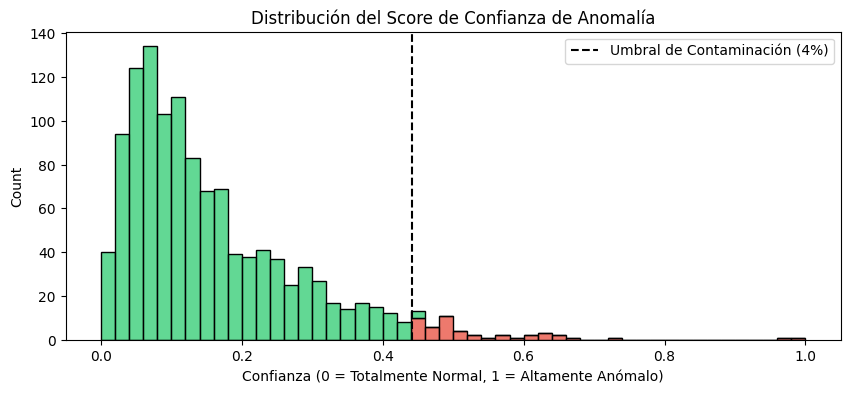

In [60]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df_analizado, x='CONFIANZA_ANOMALIA', hue='FLAG_FASE_A', multiple='stack', bins=50, palette=['#2ecc71', '#e74c3c'])
plt.axvline(x=df_analizado[df_analizado['FLAG_FASE_A'] == 1]['CONFIANZA_ANOMALIA'].min(), color='black', linestyle='--', label='Umbral de Contaminación (4%)')
plt.title('Distribución del Score de Confianza de Anomalía')
plt.xlabel('Confianza (0 = Totalmente Normal, 1 = Altamente Anómalo)')
plt.legend()
plt.show()

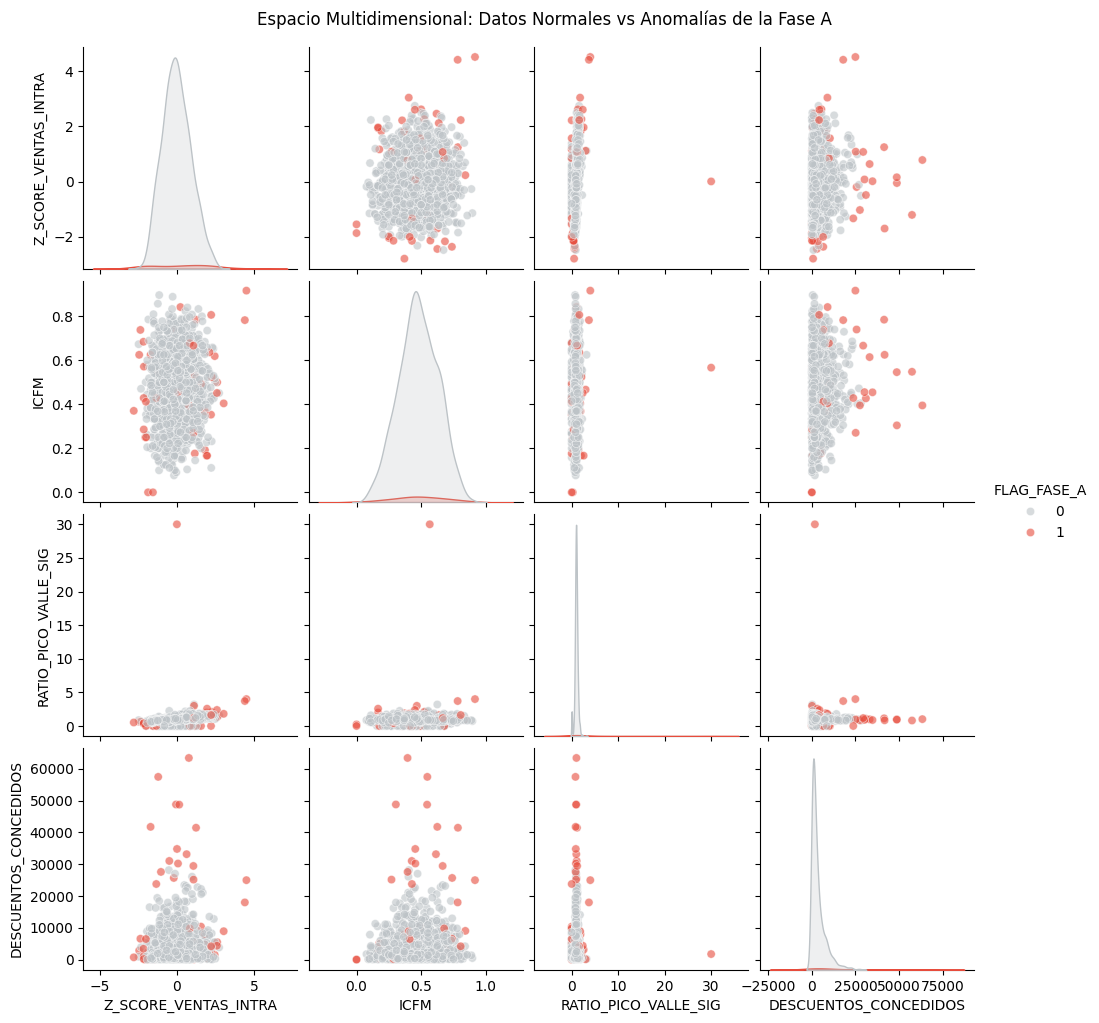

In [61]:
# Visualización de Fronteras de Aislamiento Multidimensional
features_plot = ['Z_SCORE_VENTAS_INTRA', 'ICFM', 'RATIO_PICO_VALLE_SIG', 'DESCUENTOS_CONCEDIDOS']

sns.pairplot(
    df_analizado,
    vars=features_plot,
    hue='FLAG_FASE_A',
    palette={0: '#bdc3c7', 1: '#e74c3c'}, # Gris normales, Rojo anomalías
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Espacio Multidimensional: Datos Normales vs Anomalías de la Fase A', y=1.02)
plt.show()

 ## 4. Fase B - Motor de Reglas de Negocio (Severidad y Justificación)

 En esta fase pasamos los sospechosos marcados por la **Fase A** por un embudo de

 reglas lógicas de negocio. Aquí separamos falsos positivos de patrones perversos reales,

 clasificamos su severidad (Baja, Media, Alta) y construimos una explicación comprensible

 para un gerente de ventas.

In [62]:
def aplicar_fase_b_reglas(row):
    # Si la Fase A no la catalogó como anomalía, no levantamos alerta de negocio
    if row['FLAG_FASE_A'] == 0:
        return 'SIN_ALERTA', 'Baja', 'Comportamiento dentro del rango operativo normal.'

    # Regla 1: Patrón Alta Fantasma (Pico inusual + Desierto posterior + Alto Descuento)
    if (row['Z_SCORE_VENTAS_INTRA'] > 2.5) and (row['CONSUMO_MES_SIG'] < 15.0) and (row['ICFM'] > 0.7):
        return ('ALTA_FANTASMA',
                'Alta',
                f"Venta inusualmente alta de {row['VENTAS_CANTIDAD']:.0f} líneas (Z-score: {row['Z_SCORE_VENTAS_INTRA']:.2f}) concentrada fuertemente a fin de mes ({row['ICFM']*100:.1f}%), seguida de un consumo casi nulo en el mes posterior ({row['CONSUMO_MES_SIG']:.1f} min). Alto riesgo de manipulación de incentivos.")

    # Regla 2: Retención Especulativa (Conducta Protesta: Mes anterior bloqueado + Pico actual)
    if (row['Z_SCORE_VENTAS_INTRA'] > 2.0) and (row['VENTAS_MES_ANT'] == 0) and (row['RATIO_PICO_VALLE_ANT'] > 5.0):
        return ('RETENCION_ESPECULATIVA',
                'Alta',
                f"Venta de {row['VENTAS_CANTIDAD']:.0f} líneas disparada abruptamente luego de haber reportado CERO ventas el mes anterior. Comportamiento consistente con acaparamiento deliberado para beneficio de bonos.")

    # Regla 3: Desviación General con Alto Descuento (Alerta de menor prioridad)
    if (row['Z_SCORE_VENTAS_INTRA'] > 2.0) and (row['DESCUENTOS_CONCEDIDOS'] > 10000):
         return ('PICO_CON_DESCUENTO_EXCESIVO',
                'Media',
                f"Pico de venta (Z-score: {row['Z_SCORE_VENTAS_INTRA']:.2f}) impulsado por un volumen inusual de descuentos ($ {row['DESCUENTOS_CONCEDIDOS']:.0f}). Requiere revisión de rentabilidad.")

    # Regla de escape o descarte por defecto
    return ('ANOMALIA_ESTADISTICA_SIMPLE',
            'Baja',
            f"El registro presenta un comportamiento estadísticamente inusual, pero no cumple con los patrones críticos específicos de fraude de comisiones.")


In [63]:
# Aplicamos la Fase B únicamente sobre las filas que tienen alertas de la Fase A
resultados_reglas = df_analizado.apply(aplicar_fase_b_reglas, axis=1)

df_analizado['TIPO_ALERTA'] = [r[0] for r in resultados_reglas]
df_analizado['SEVERIDAD'] = [r[1] for r in resultados_reglas]
df_analizado['JUSTIFICACION'] = [r[2] for r in resultados_reglas]

print("Fase B finalizada. Las anomalías estadísticas han sido filtradas y justificadas comercialmente.")


Fase B finalizada. Las anomalías estadísticas han sido filtradas y justificadas comercialmente.


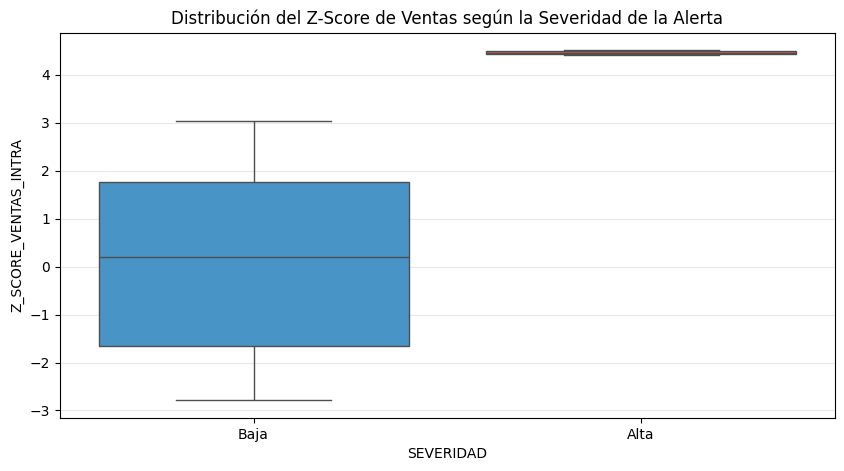

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_analizado[df_analizado['TIPO_ALERTA'] != 'SIN_ALERTA'],
    x='SEVERIDAD',
    y='Z_SCORE_VENTAS_INTRA',
    palette={'Alta': '#e74c3c', 'Media': '#f39c12', 'Baja': '#3498db'}
)
plt.title('Distribución del Z-Score de Ventas según la Severidad de la Alerta')
plt.grid(axis='y', alpha=0.3)
plt.show()

 ## 5. Resultados e Inspección de los Casos de Éxito

 Vamos a verificar si nuestro sistema híbrido detectó con precisión quirúrgica los

 dos fraudes artificiales que inyectamos al inicio de la simulación.

In [65]:
print("\n=== VERIFICACIÓN DEL CASO INYECTADO 1: ALTA FANTASMA (ASESOR_012) ===")
filtro_caso_1 = df_analizado[(df_analizado['ASESOR'] == 'ASESOR_012') & (df_analizado['ANIO'] == 2024) & (df_analizado['MES'] == 10)]
print(filtro_caso_1[['ASESOR', 'ANIO', 'MES', 'VENTAS_CANTIDAD', 'TIPO_ALERTA', 'SEVERIDAD', 'JUSTIFICACION']].to_string())

print("\n=== VERIFICACIÓN DEL CASO INYECTADO 2: RETENCIÓN ESPECULATIVA (ASESOR_035) ===")
filtro_caso_2 = df_analizado[(df_analizado['ASESOR'] == 'ASESOR_035') & (df_analizado['ANIO'] == 2025) & (df_analizado['MES'] == 4)]
print(filtro_caso_2[['ASESOR', 'ANIO', 'MES', 'VENTAS_CANTIDAD', 'TIPO_ALERTA', 'SEVERIDAD', 'JUSTIFICACION']].to_string())



=== VERIFICACIÓN DEL CASO INYECTADO 1: ALTA FANTASMA (ASESOR_012) ===
         ASESOR  ANIO  MES  VENTAS_CANTIDAD    TIPO_ALERTA SEVERIDAD                                                                                                                                                                                                  JUSTIFICACION
273  ASESOR_012  2024   10              120  ALTA_FANTASMA      Alta  Venta inusualmente alta de 120 líneas (Z-score: 4.51) concentrada fuertemente a fin de mes (91.7%), seguida de un consumo casi nulo en el mes posterior (5.2 min). Alto riesgo de manipulación de incentivos.

=== VERIFICACIÓN DEL CASO INYECTADO 2: RETENCIÓN ESPECULATIVA (ASESOR_035) ===
         ASESOR  ANIO  MES  VENTAS_CANTIDAD             TIPO_ALERTA SEVERIDAD                                                                                                                                                                      JUSTIFICACION
831  ASESOR_035  2025    4              

 ## 6. Simulación de un Sistema en Producción (Replicable)

 El gran reto de la hackatón exige que el código sea reproducible y pueda ejecutarse

 sobre un nuevo periodo sin necesidad de re-entrenar todo de forma manual.

 Empaquetamos todo el pipeline en una función de producción para demostrar cómo opera en la vida real.

In [66]:
def generar_alertas_produccion(data_completa, anio_evaluar, mes_evaluar):
    """
    Función parametrizada que procesa un mes específico, calcula sus features retrospectivas,
    aplica el modelo de Isolation Forest y levanta las alertas correspondientes.
    """
    # 1. Pipeline de ingeniería de características
    df_processed = pipeline_features(data_completa)

    # 2. Correr Fase A (Modelo Técnico)
    df_fase_a = ejecutar_fase_a_anomalias(df_processed)

    # 3. Correr Fase B (Reglas de Negocio)
    res_reglas = df_fase_a.apply(aplicar_fase_b_reglas, axis=1)
    df_fase_a['TIPO_ALERTA'] = [r[0] for r in res_reglas]
    df_fase_a['SEVERIDAD'] = [r[1] for r in res_reglas]
    df_fase_a['JUSTIFICACION'] = [r[2] for r in res_reglas]

    # 4. Filtrar únicamente para el periodo solicitado y las alertas que ameritan acción (Baja/Media/Alta)
    alertas_periodo = df_fase_a[
        (df_fase_a['ANIO'] == anio_evaluar) &
        (df_fase_a['MES'] == mes_evaluar) &
        (df_fase_a['TIPO_ALERTA'] != 'SIN_ALERTA')
    ]

    # Retornar el reporte comercial final ordenado por gravedad
    reporte = alertas_periodo[[
        'ASESOR', 'ANIO', 'MES', 'REGION', 'VENTAS_CANTIDAD', 'TIPO_ALERTA', 'SEVERIDAD', 'JUSTIFICACION'
    ]].sort_values(by='SEVERIDAD', ascending=False)

    return reporte


In [67]:
print("\n=== SIMULACIÓN DEL SISTEMA EN PRODUCCIÓN PARA ABRIL DE 2025 ===")
reporte_abril = generar_alertas_produccion(df_raw, 2025, 4)
print(f"Número de alertas críticas detectadas para el periodo: {reporte_abril.shape[0]}")
print(reporte_abril.head(10))


=== SIMULACIÓN DEL SISTEMA EN PRODUCCIÓN PARA ABRIL DE 2025 ===
Número de alertas críticas detectadas para el periodo: 2
         ASESOR  ANIO  MES    REGION  VENTAS_CANTIDAD                  TIPO_ALERTA SEVERIDAD                                      JUSTIFICACION
999  ASESOR_042  2025    4      CALI               94  ANOMALIA_ESTADISTICA_SIMPLE      Baja  El registro presenta un comportamiento estadís...
831  ASESOR_035  2025    4  MEDELLIN              115       RETENCION_ESPECULATIVA      Alta  Venta de 115 líneas disparada abruptamente lue...


## Anexos

In [68]:
# Extracción de Feature Importance por contraste de perfiles
features_tecnicos = ['Z_SCORE_VENTAS_INTRA', 'ICFM', 'RATIO_PICO_VALLE_SIG', 'DESCUENTOS_CONCEDIDOS']

# Calcular medias por grupo
perfil = df_analizado.groupby('FLAG_FASE_A')[features_tecnicos].mean().T
perfil.columns = ['Media_Normal', 'Media_Anomalia']

# Calcular impacto relativo
perfil['Desviación_Relativa'] = (perfil['Media_Anomalia'] - perfil['Media_Normal']) / (perfil['Media_Normal'] + 1e-5)
perfil['Importancia_Absoluta'] = perfil['Desviación_Relativa'].abs()
perfil_ordenado = perfil.sort_values(by='Importancia_Absoluta', ascending=False)

print("=== FEATURE IMPORTANCE ESTIMADA (PERFILAMIENTO NO SUPERVISADO) ===")
print(perfil_ordenado[['Media_Normal', 'Media_Anomalia', 'Desviación_Relativa']])

=== FEATURE IMPORTANCE ESTIMADA (PERFILAMIENTO NO SUPERVISADO) ===
                       Media_Normal  Media_Anomalia  Desviación_Relativa
Z_SCORE_VENTAS_INTRA      -0.013578        0.325862           -25.018426
DESCUENTOS_CONCEDIDOS   3473.079071    14902.987083             3.291001
RATIO_PICO_VALLE_SIG       0.957682        1.696814             0.771785
ICFM                       0.476567        0.477380             0.001706


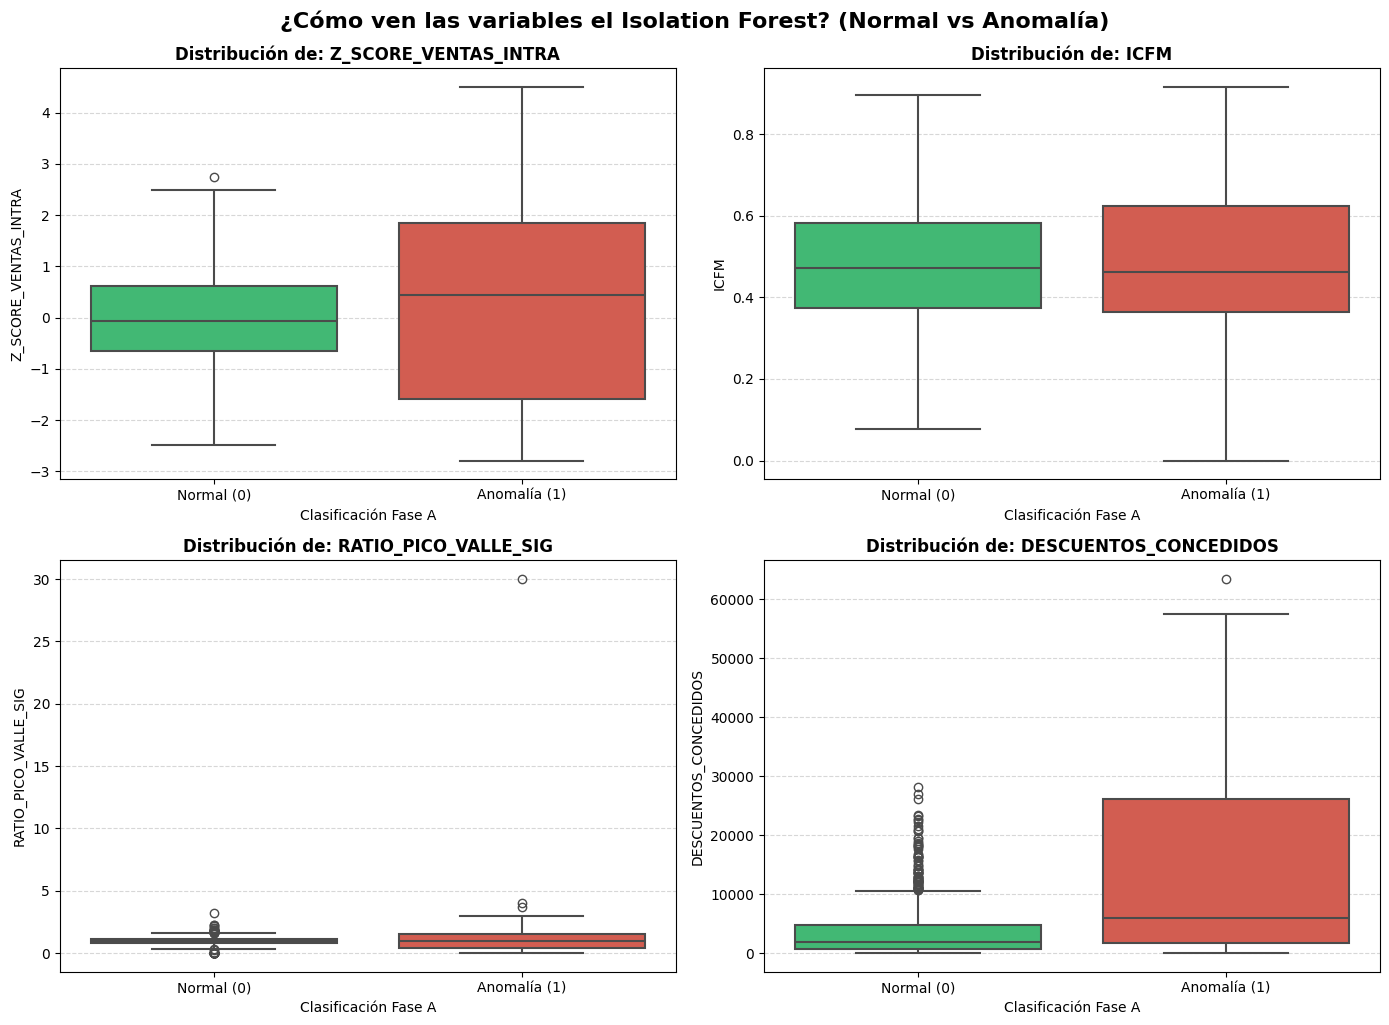

In [69]:
features_tecnicos = ['Z_SCORE_VENTAS_INTRA', 'ICFM', 'RATIO_PICO_VALLE_SIG', 'DESCUENTOS_CONCEDIDOS']

# Crear una cuadrícula de 2x2 para los gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Aplanar la matriz para iterar fácilmente

for i, col in enumerate(features_tecnicos):
    sns.boxplot(
        data=df_analizado,
        x='FLAG_FASE_A',
        y=col,
        ax=axes[i],
        palette={0: '#2ecc71', 1: '#e74c3c', '0': '#2ecc71', '1': '#e74c3c'},
        linewidth=1.5
    )
    axes[i].set_title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Clasificación Fase A')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(['Normal (0)', 'Anomalía (1)'])
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustar diseño para evitar solapamientos
plt.tight_layout()
plt.suptitle('¿Cómo ven las variables el Isolation Forest? (Normal vs Anomalía)', y=1.02, fontsize=16, fontweight='bold')
plt.show()